# PART4_Select_HBs
Not all HBs are important to predict phenotypes.

So, check accuracy against the number of HBs selected by importance of each models

In [1]:
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set()

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

from modules.make_data_for_prediction import make_data, make_data_for_Tuning
from modules.tuning import tuning_LightGBM, tuning_Lasso, tuning_ElasticNet, tuning_RandomForest
from modules.training_module import train_GBLUP, GBLUP_coef, train_lightgbm, train_randomforest, train_Lasso, train_Enet

# Calculate accuracy of the model based on selected haplotype blocks

## Extract 3000~10 Haplotype blocks based on importances
importance means feature importances, coefs, p-values calculated by model

In [23]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
genotype = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")

for trait_name in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    with open('../data/PART3_Model_comparison/Compare_models_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        summary = pickle.load(p)
    summary = pd.DataFrame(summary)
    for model in ['GBLUP', 'LGBM', 'RF', 'Lasso', 'Enet']:
        for HB_num in [3000, 2000, 1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 75, 50, 25, 10]:
            path = "../data/PART4_Select_HBs/selected_genotype/{}_{}_{}.csv".format(trait_name, model, HB_num)                
            if model == "LGBM":
                imp = np.mean([np.mean(i, axis=0) for i in summary.loc[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 2] == "LGBM"), 6].values], axis=0)
            else:
                imp = np.mean(summary.loc[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 2] == model), 6].values, axis=0)
            selected_indices = np.argsort(np.abs(imp))[::-1][:HB_num]
            genotype.loc[np.sort(selected_indices), :].to_csv(path, index=None)

In [22]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
genotype = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
genotype = genotype.iloc[:, :2]

for trait_name in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    with open('../data/PART3_Model_comparison/Compare_models_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        summary = pickle.load(p)
    summary = pd.DataFrame(summary)
    for model in ['GBLUP', 'LGBM', 'RF', 'Lasso', 'Enet']:
        if model == "LGBM":
            imp = np.mean([np.mean(i, axis=0) for i in summary.loc[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 2] == "LGBM"), 6].values], axis=0)
        else:
            imp = np.mean(summary.loc[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 2] == model), 6].values, axis=0)
        genotype[f"{trait_name}_{model}"] = np.round(imp, 3)
genotype.to_csv("../data/PART4_Select_HBs/HB_imp_table_for_Supp.csv")

## Parameter tuning

In [ ]:
def make_data_for_Tuning_selected_HBs(model, HB_num, family, family_list, trait_name, phenotype, CV):
    genotype = "../data/PART4_Select_HBs/selected_genotype/{}_{}_{}.csv".format(trait_name, model, HB_num)                
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False)
    return test_data, train_data

family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV=5
optuna_seed=1024
trait_names = ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]

for trait_name in trait_names:
    Lasso_params = []
    Enet_params = []
    LGBM_params = []
    RF_params = []
    print(trait_name)
    for HB_num in [3000, 2000, 1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 75, 50, 25, 10]:
        print(HB_num)
        # Tuning Lasso
        test_data, train_data = make_data_for_Tuning_selected_HBs("Lasso", HB_num, family, family_list, trait_name, phenotype, CV)
        for i in range(CV):
            train_data_CVn = train_data[i]
            X = train_data_CVn[0]; y = train_data_CVn[1]
            Lasso_params.append([trait_name, HB_num, i, tuning_Lasso(X, y)])

        # Tuning Enet
        test_data, train_data = make_data_for_Tuning_selected_HBs("Enet", HB_num, family, family_list, trait_name, phenotype, CV)
        for i in range(CV):
            train_data_CVn = train_data[i]
            X = train_data_CVn[0]; y = train_data_CVn[1]
            Enet_params.append([trait_name, HB_num, i, tuning_ElasticNet(X, y)])

        # Tuning LGBM
        test_data, train_data = make_data_for_Tuning_selected_HBs("LGBM", HB_num, family, family_list, trait_name, phenotype, CV)
        for i in range(CV):
            train_data_CVn = train_data[i]
            X = train_data_CVn[0]; y = train_data_CVn[1]
            LGBM_params.append([trait_name, HB_num, i, tuning_LightGBM(X, y)])

        # Tuning RF
        test_data, train_data = make_data_for_Tuning_selected_HBs("RF", HB_num, family, family_list, trait_name, phenotype, CV)
        for i in range(CV):
            train_data_CVn = train_data[i]
            X = train_data_CVn[0]; y = train_data_CVn[1]
            RF_params.append([trait_name, HB_num, i, tuning_RandomForest(X, y)])
    pd.DataFrame(Lasso_params).to_csv("../data/PART4_Select_HBs/Lasso_selected_HBs_{}_params.csv".format(trait_name))
    pd.DataFrame(Enet_params).to_csv("../data/PART4_Select_HBs/Enet_selected_HBs_{}_params.csv".format(trait_name))
    pd.DataFrame(LGBM_params).to_csv("../data/PART4_Select_HBs/LGBM_selected_HBs_{}_params.csv".format(trait_name))
    pd.DataFrame(RF_params).to_csv("../data/PART4_Select_HBs/RF_selected_HBs_{}_params.csv".format(trait_name))

## Train models using selected HBs

In [ ]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV=5

summary = []
for trait_name in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    for HB_num in [3000, 2000, 1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 75, 50, 25, 10]:
        for model in ['GBLUP', 'LGBM', 'Lasso', 'Enet', 'RF']:
            print(trait_name, model, HB_num)
            genotype = "../data/PART4_Select_HBs/selected_genotype/{}_{}_{}.csv".format(trait_name, model, HB_num)    
            test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False, log=False)
            
            for i in range(CV):
                print("CV{}".format(i))
                # parameters
                if model != 'GBLUP':
                    params = pd.read_csv("../data/PART4_Select_HBs/{}_selected_HBs_{}_params.csv".format(model, trait_name), index_col=0)
                    params.columns = ["trait", "HB_num", "CV", "params"]
                    params = ast.literal_eval(params.loc[(params["trait"] == trait_name) & (params["CV"] == i) & (params["HB_num"] == HB_num), "params"].values[0])
                tmp_test_data = test_data[i]
                tmp_train_data = train_data[i]

                if model == 'GBLUP':
                    test_pred, h2, r2, acc_RIL = train_GBLUP(tmp_test_data, tmp_train_data, genotype)
                    imps = []
                elif model == 'LGBM':
                    test_preds, r2, acc_RIL, imps = train_lightgbm(tmp_test_data, tmp_train_data, CV, params)
                    test_pred = np.mean(test_preds, axis=0)
                elif model == 'Lasso':
                    test_pred, r2, acc_RIL, imps = train_Lasso(tmp_test_data, tmp_train_data, params)
                elif model == 'Enet':
                    test_pred, r2, acc_RIL, imps = train_Enet(tmp_test_data, tmp_train_data, params)
                elif model == 'RF':
                    test_pred, r2, acc_RIL, imps = train_randomforest(tmp_test_data, tmp_train_data, CV, params)

                summary.append([trait_name, HB_num, model, i, test_pred, r2, acc_RIL, imps])

with open('../data/PART4_Select_HBs/Compare_models_by_all_RILs_selected_HBs.pic.bin', 'wb') as p:
    pickle.dump(summary, p)

LW_mean


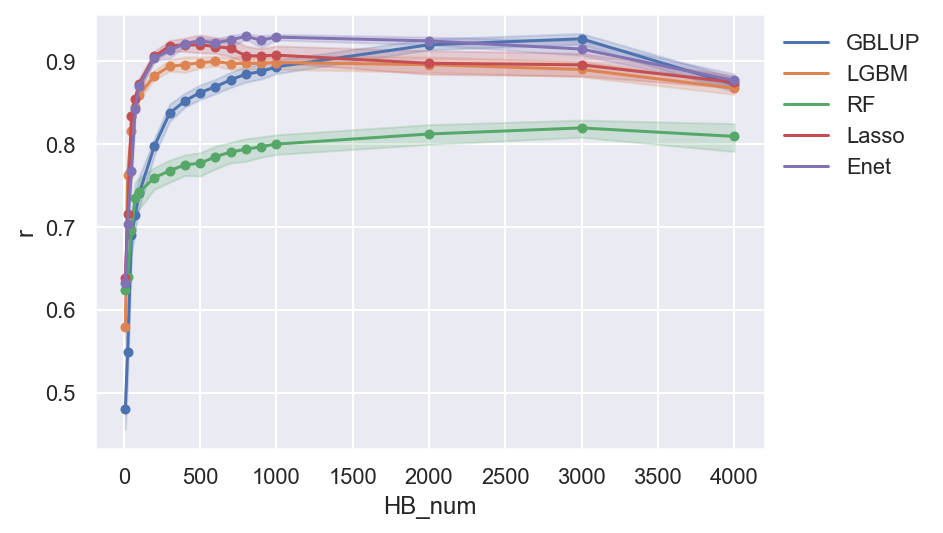

GN_mean


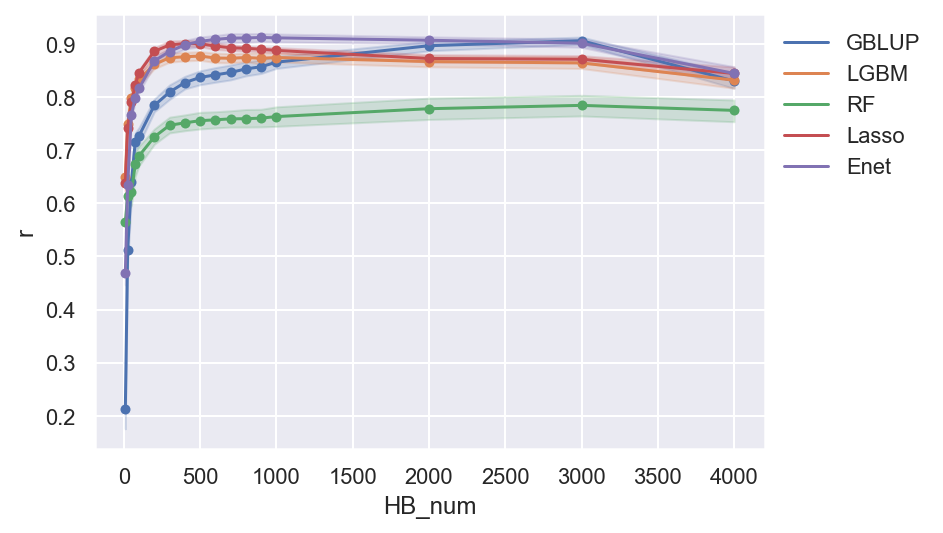

LL_mean


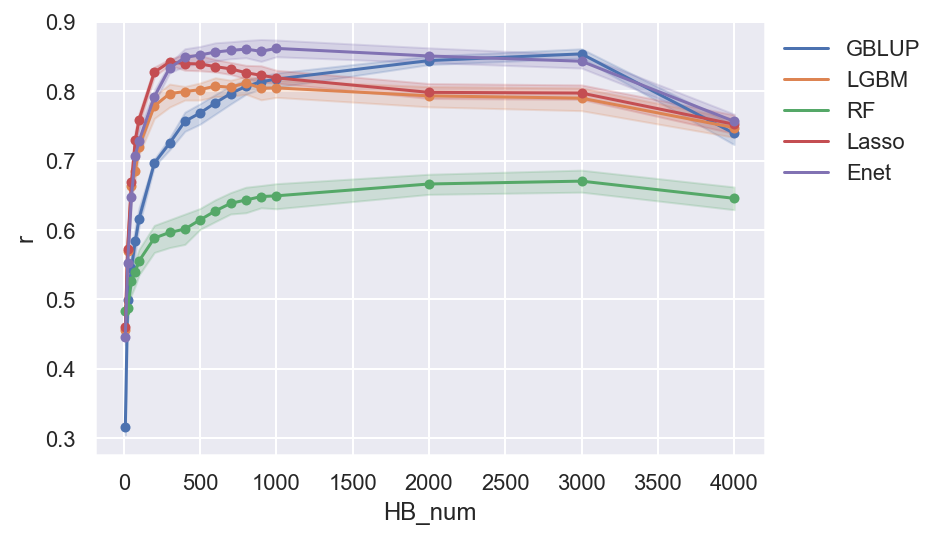

DTH_mean


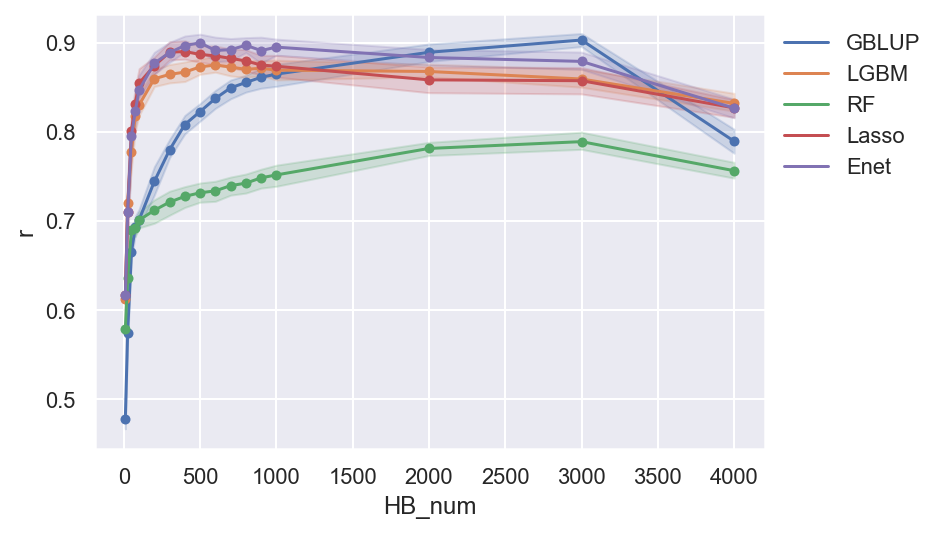

PN_mean


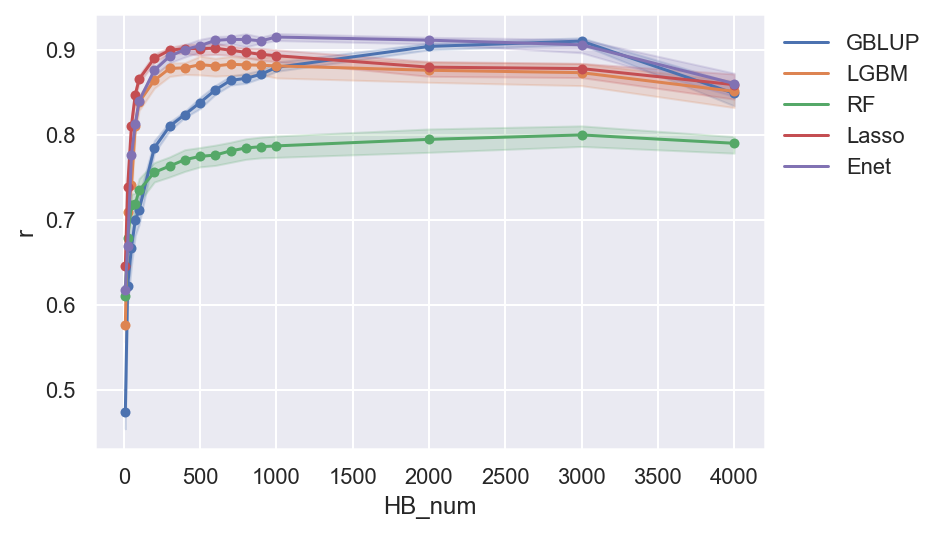

Area.size.AS..mm2.


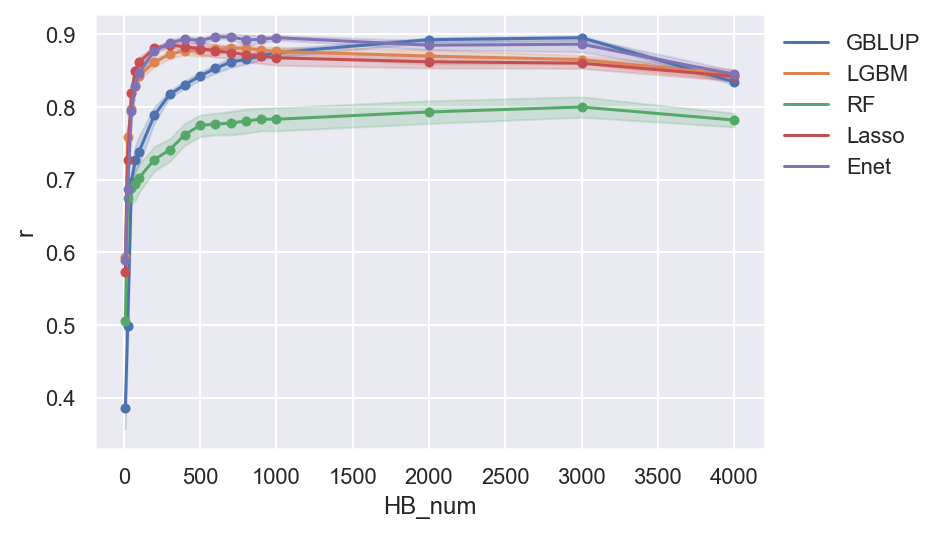

In [2]:
with open('../data/PART4_Select_HBs/Compare_models_by_all_RILs_selected_HBs.pic.bin', 'rb') as p:
    summary = pickle.load(p)
summary = pd.DataFrame(summary)

for trait_name in ["LW_mean", "LL_mean", "GN_mean", "Area.size.AS..mm2.", "DTH_mean", "PN_mean"]:
    with open('../data/PART3_Model_comparison/Compare_models_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        each_summary = pickle.load(p)
    each_summary = pd.DataFrame(each_summary)
    each_summary["HB_num"] = np.repeat(4000, each_summary.shape[0])
    each_summary = each_summary.iloc[:, [0,7,2,1,3,4,5,6]]
    each_summary.columns = range(8)
    each_summary = each_summary.loc[each_summary.iloc[:, 2].isin(["GBLUP", "LGBM", "RF", "Lasso", "Enet"]), :]
    summary = pd.concat([each_summary, summary])
summary = summary.reset_index(drop=True)

for trait_name in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    print(trait_name)
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    ax = sns.lineplot(data=trait_summary, x="HB_num", y="r", hue="model", marker="o", markersize=5, markeredgewidth=0)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title=None, frameon=False)
    plt.show()

In [4]:
# Check model and HB number for top 3 accuracy 
for trait_name in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    print(trait_name)
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    trait_summary = trait_summary.groupby(["HB_num", "model"]).mean().reset_index()
    display(trait_summary.sort_values(by="r", ascending=False).iloc[:3, :])

LW_mean


,HB_num,model,CV,r
55,800,Enet,2.0,0.929925
65,1000,Enet,2.0,0.929035
76,3000,GBLUP,2.0,0.926981


GN_mean


,HB_num,model,CV,r
60,900,Enet,2.0,0.912034
65,1000,Enet,2.0,0.911318
55,800,Enet,2.0,0.911081


LL_mean


...

,HB_num,model,CV,r
76,3000,GBLUP,2.0,0.902798
40,500,Enet,2.0,0.899664
55,800,Enet,2.0,0.896880


PN_mean


,HB_num,model,CV,r
65,1000,Enet,2.0,0.915041
50,700,Enet,2.0,0.912236
55,800,Enet,2.0,0.912157


Area.size.AS..mm2.


,HB_num,model,CV,r
45,600,Enet,2.0,0.896620
50,700,Enet,2.0,0.896603
65,1000,Enet,2.0,0.895472


## Best prediction model by ElasticNet

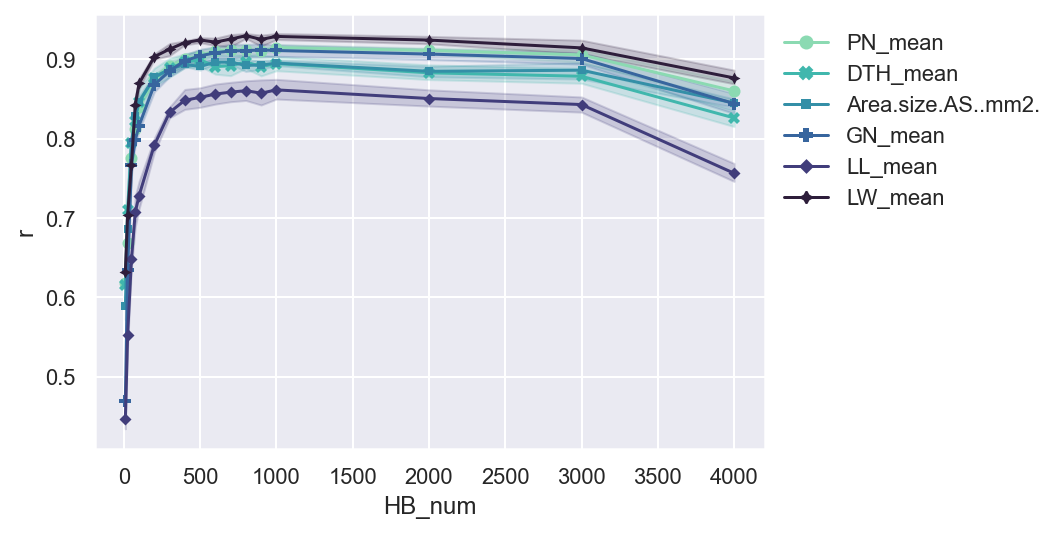

In [5]:
Enet_summary = summary.iloc[:, [0,1,2,3,5]]
Enet_summary = Enet_summary[Enet_summary.iloc[:, 2] == "Enet"]
Enet_summary.columns = ["trait", "HB_num", "model", "CV", "r"]
palette = sns.color_palette("mako_r", 6)
ax = sns.lineplot(data=Enet_summary, x="HB_num", y="r", hue="trait", style="trait", palette=palette, markers=True, dashes=False, markeredgewidth=0)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title=None, frameon=False,)
plt.show()

LW_mean Enet 800
all 0.9313196156137555
all 0.9239380992399725
all 0.9345553727028942
all 0.9283636814133264
all 0.9314458745071738


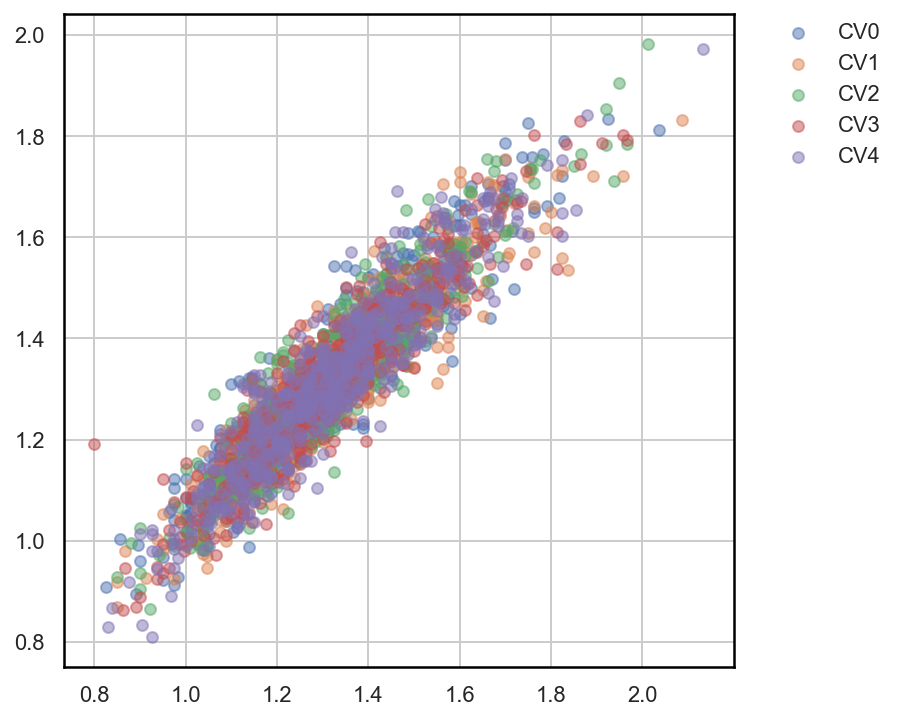

GN_mean Enet 900
all 0.9055961174198276
all 0.9149131595902054
all 0.9251961448800792
all 0.8980822566170074
all 0.9163814013384299


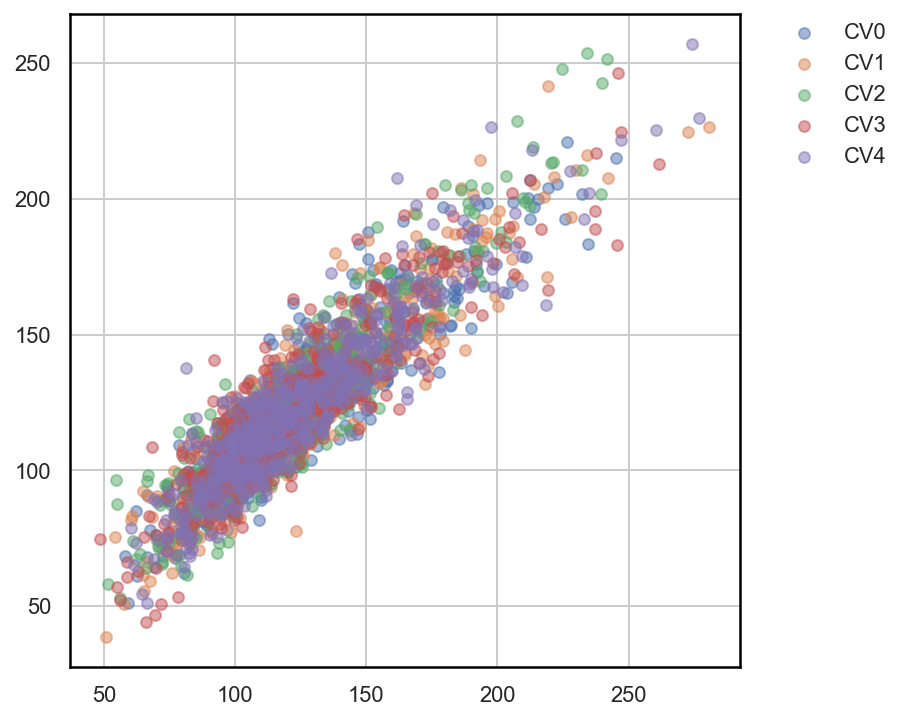

LL_mean Enet 1000
all 0.8489561576849582
all 0.8567425760989492
all 0.8709260206870438
all 0.8467761239219217
all 0.8849709957127013


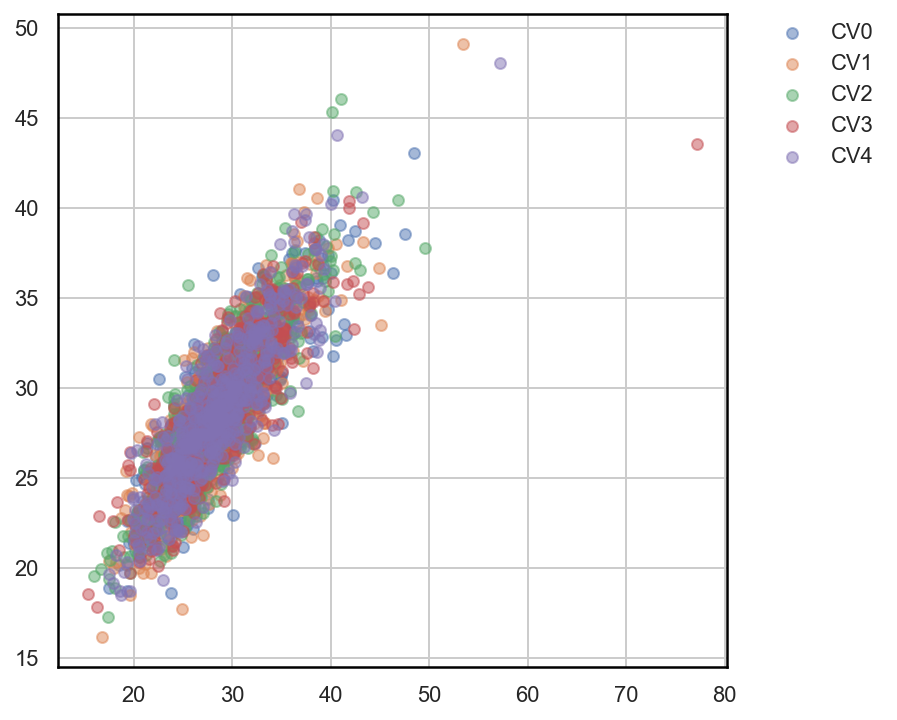

DTH_mean Enet 500
all 0.8944691867522166
all 0.8968018808440563
all 0.8858517666869796
all 0.9168731328171557
all 0.9043236013973339


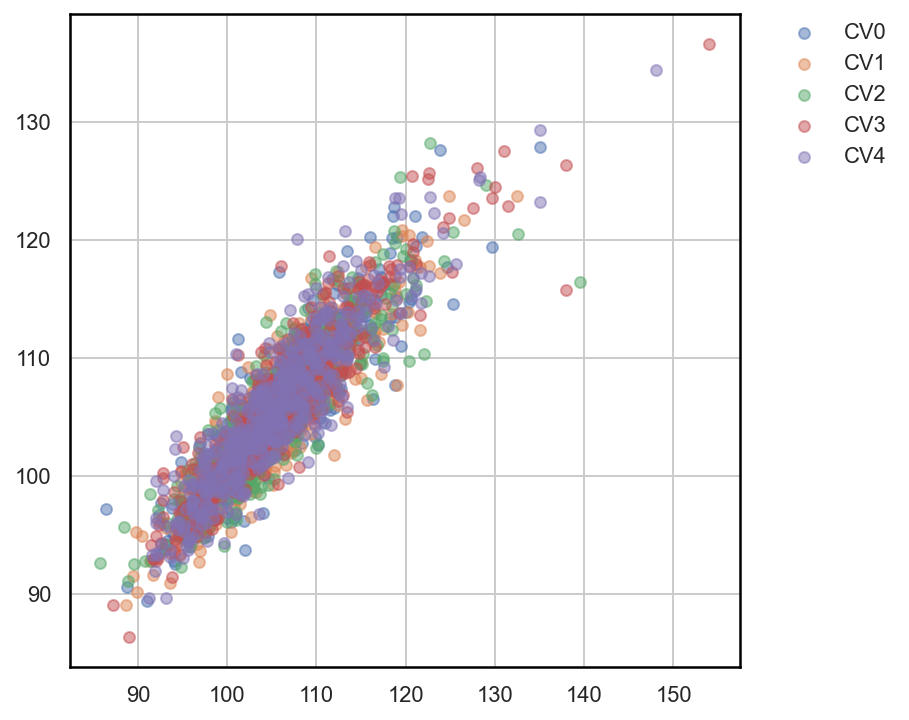

PN_mean Enet 1000
all 0.9195064732495339
all 0.9084775961380429
all 0.9097522767977798
all 0.9196125819325517
all 0.9178554068535245


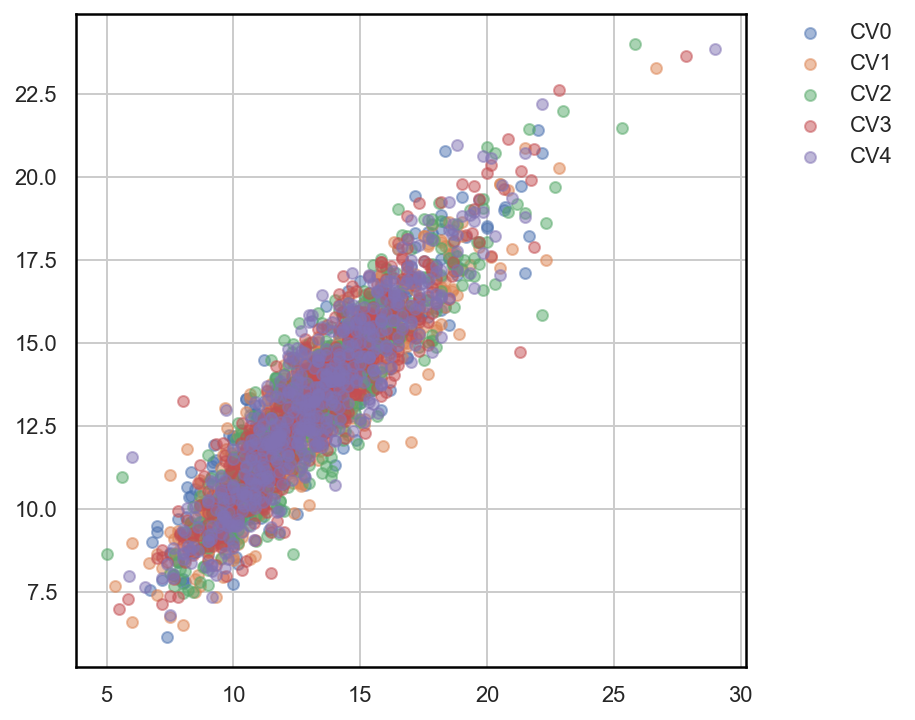

Area.size.AS..mm2. Enet 600
all 0.8939069820220573
all 0.8968296131963929
all 0.9054377786484104
all 0.8926248339814823
all 0.8942991666557275


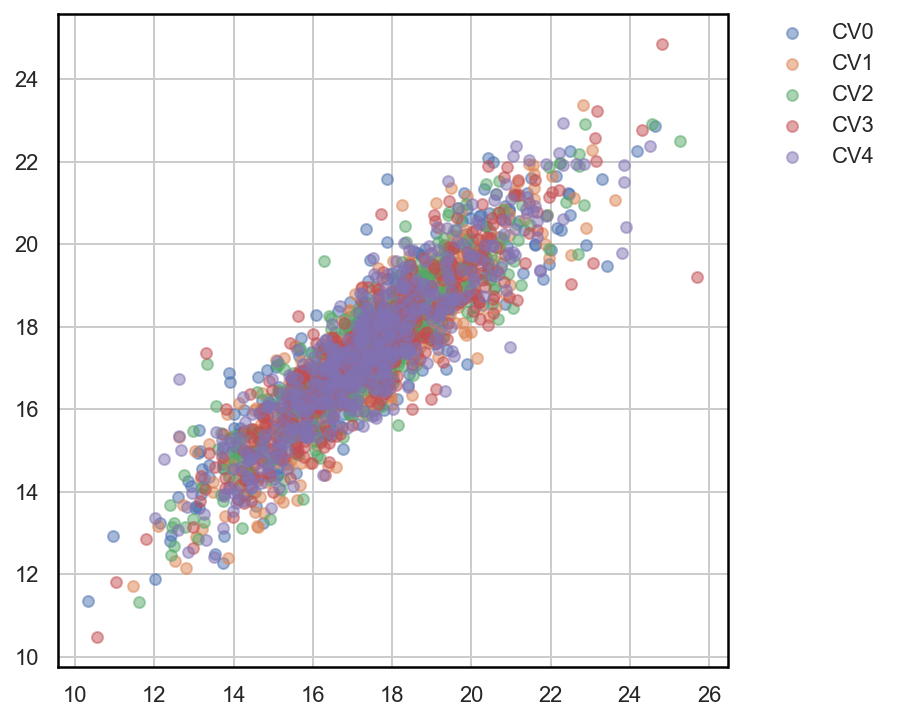

In [6]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV = 5

for trait_name in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    
    # select best HB_num and model
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    trait_summary = trait_summary[trait_summary.model == "Enet"]
    trait_summary = trait_summary.groupby(["HB_num", "model"]).mean().reset_index()
    HB_num = trait_summary.sort_values(by="r", ascending=False).iloc[0, 0]
    model = trait_summary.sort_values(by="r", ascending=False).iloc[0, 1]
    
    print(trait_name, model, HB_num)
    genotype = "../data/PART4_Select_HBs/selected_genotype/{}_{}_{}.csv".format(trait_name, model, HB_num)   
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False, log=False)
    test_preds = summary[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 1] == HB_num) & (summary.iloc[:, 2] == model)].iloc[:, 4].values
    sns.set_style('whitegrid')
    
    fig, ax = plt.subplots(figsize=(6,6))
    scatter_data = pd.DataFrame()
    for i, tmp_test_data in enumerate(test_data):
        y = tmp_test_data[1].values
        y_pre = test_preds[i]
        print("all", np.corrcoef([y[np.argsort(y)], y_pre[np.argsort(y)]])[0,1])
        if i == 0:
            min_val = min(min(y), min(y_pre))
            max_val = max(max(y), max(y_pre))
        else:
            min_val = min(min_val, min(min(y), min(y_pre)))
            max_val = max(max_val, max(max(y), max(y_pre)))
        ax.scatter(x=y, y=y_pre, s=30, linewidth=1, alpha=0.5, label="CV{}".format(i))
#     ax.plot([min_val, max_val], [min_val, max_val], ls="--", c=".3")
    legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    frame = legend.get_frame()
    frame.set_color('white')
    for sp in ["top", "left", "right", "bottom"]:
        ax.spines[sp].set_color('black')
    plt.show()

LW_mean 800 Enet
18
19


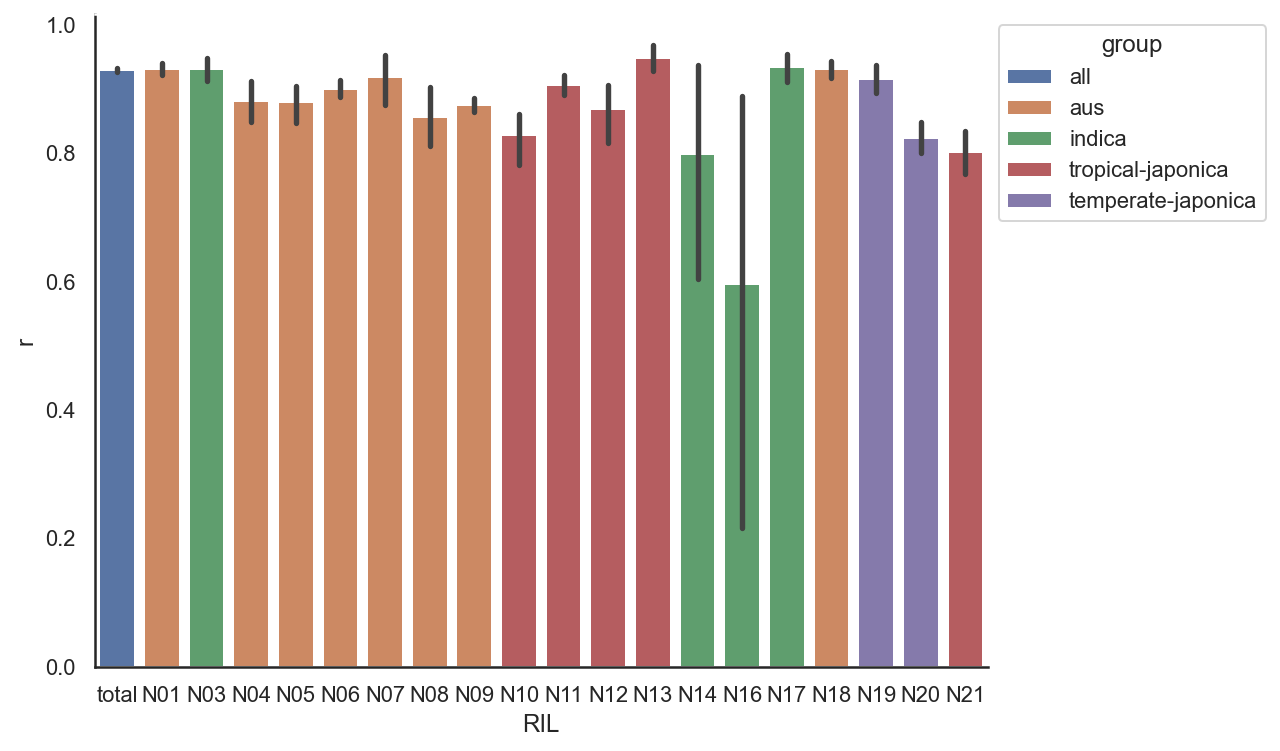

GN_mean 900 Enet
16
19


<Figure size 432x288 with 0 Axes>

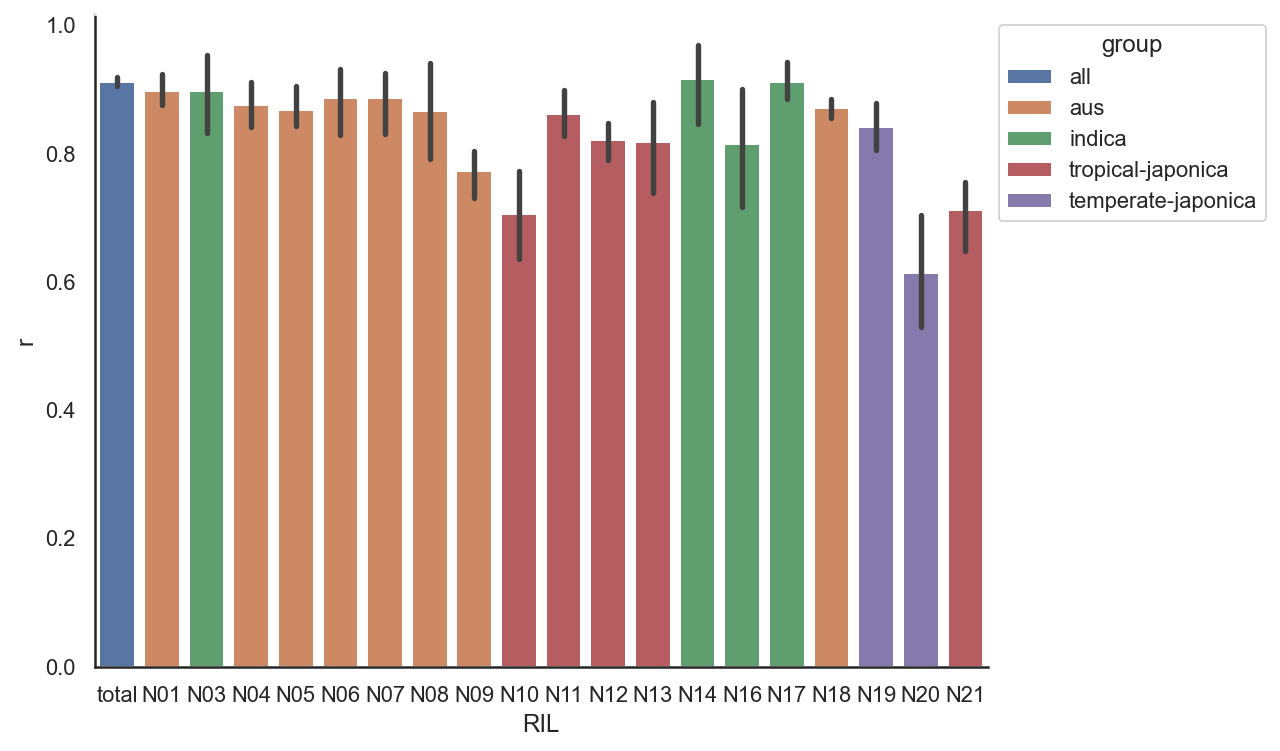

LL_mean 1000 Enet
13
18


<Figure size 432x288 with 0 Axes>

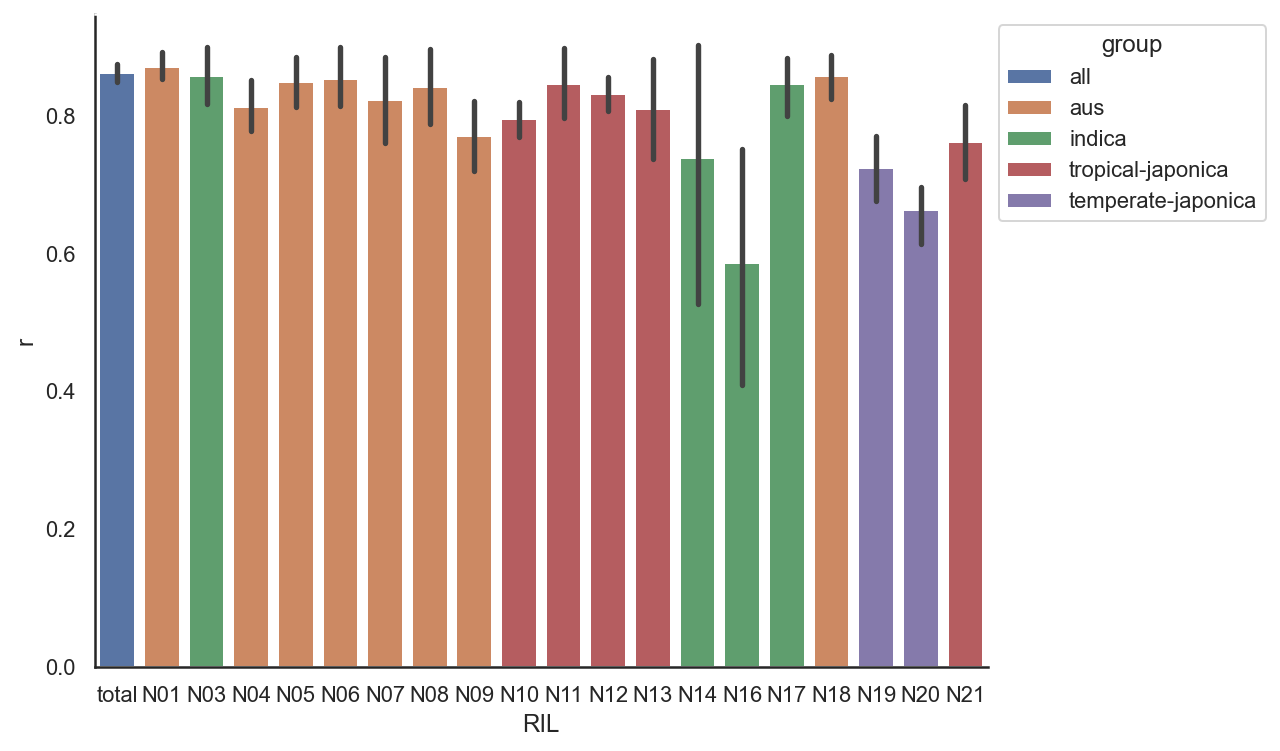

DTH_mean 500 Enet
14
20


<Figure size 432x288 with 0 Axes>

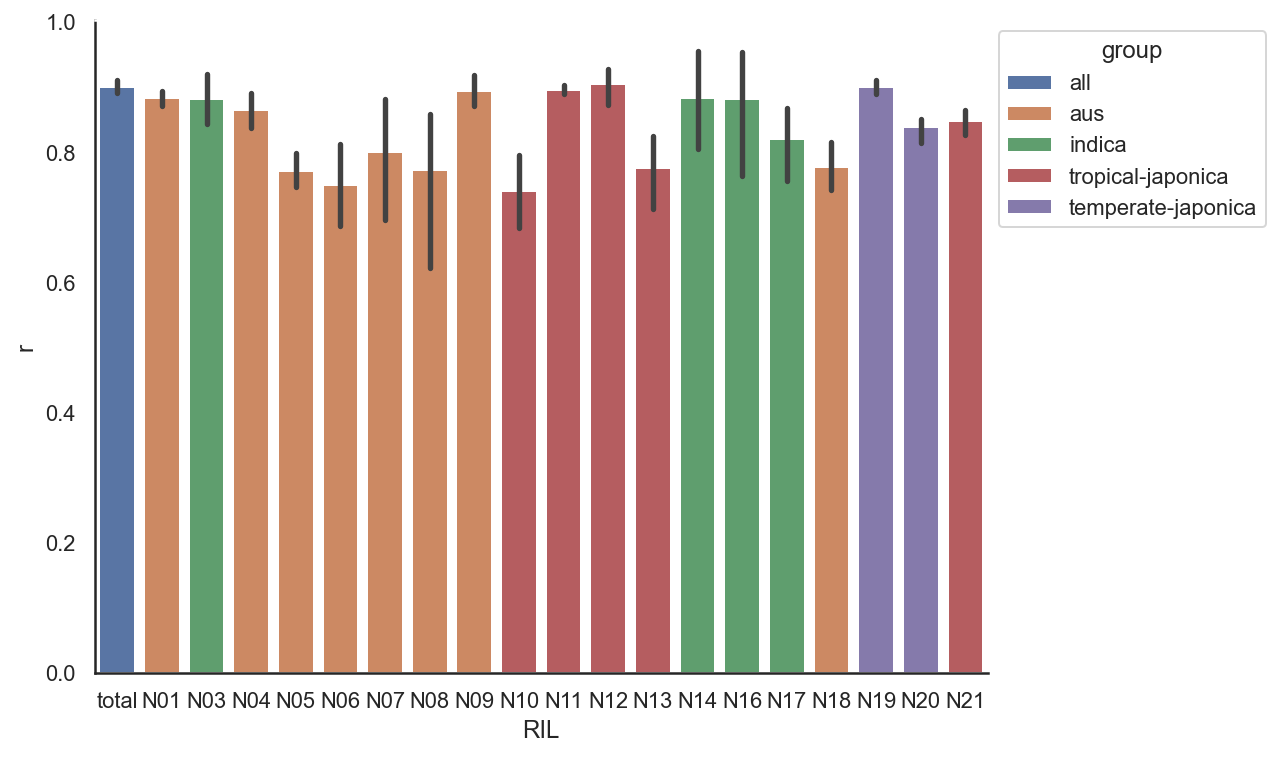

PN_mean 1000 Enet
16
19


<Figure size 432x288 with 0 Axes>

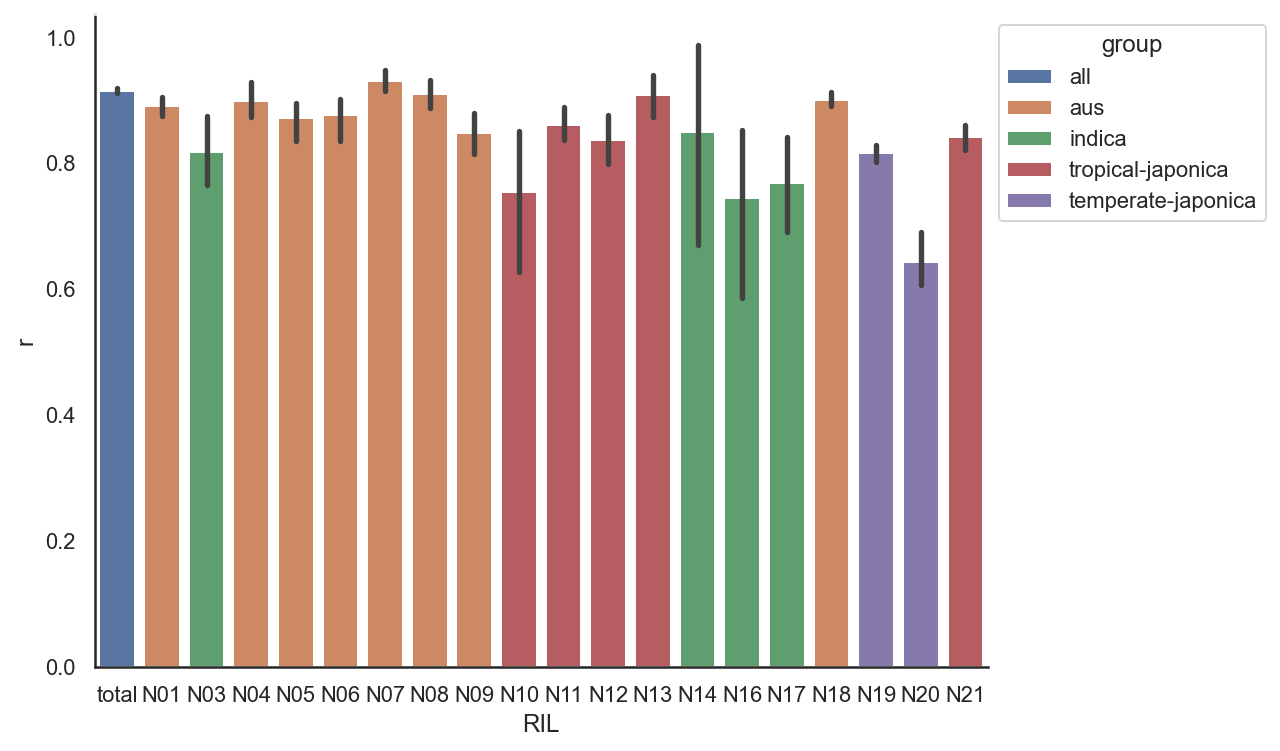

Area.size.AS..mm2. 600 Enet
10
17


<Figure size 432x288 with 0 Axes>

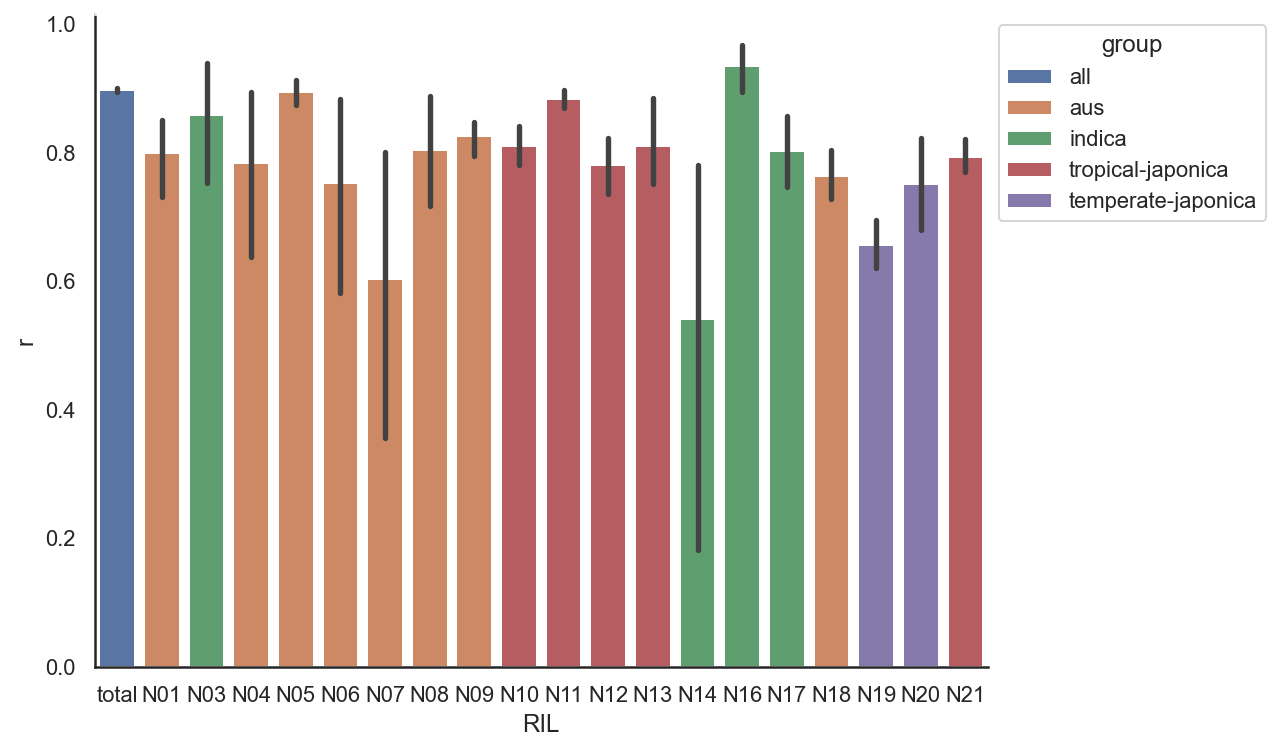

<Figure size 432x288 with 0 Axes>

In [19]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV = 5

founder = pd.read_excel("../data/phenotype_data/Founders.xlsx")
for trait_name in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    
    # select best HB_num and model
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    trait_summary = trait_summary[trait_summary.model == "Enet"]
    trait_summary = trait_summary.groupby(["HB_num", "model"]).mean().reset_index()
    HB_num = trait_summary.sort_values(by="r", ascending=False).iloc[0, 0]
    model = trait_summary.sort_values(by="r", ascending=False).iloc[0, 1]
    
    print(trait_name, HB_num, model)
    
    data_for_vis = []
    tmp_summary = summary[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 1] == HB_num) & (summary.iloc[:, 2] == model)].iloc[:, 6].values
    for CV in range(5):
        total_acc = summary[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 1] == HB_num) & (summary.iloc[:, 2] == model) & (summary.iloc[:, 3] == CV)].iloc[:, 5].values[0]
        data_for_vis.append([CV, total_acc, "total", "all"])
        for i in range(len(tmp_summary[CV][0])):
            data_for_vis.append([CV, tmp_summary[CV][0][i], tmp_summary[CV][1][i], founder[founder["ID"] == tmp_summary[CV][1][i]].group.values[0]])
    data_for_vis = pd.DataFrame(data_for_vis)
    data_for_vis.columns = ["CV", "r", "RIL", "group"]
    print(sum(data_for_vis.groupby("RIL").mean().r > 0.8))
    print(sum(data_for_vis.groupby("RIL").mean().r > 0.7))
    plt.figure(figsize=(8,6))
    sns.set_style('white')
    ax = sns.barplot(x="RIL", y="r", hue="group", data=data_for_vis, dodge=False)
#     sns.stripplot(x="RIL", y="r", data=data_for_vis, dodge=True, edgecolor="black", linewidth=.75, ax=ax)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    for sp in ["top", "right"]:
        ax.spines[sp].set_color('white')
    plt.show()
    plt.clf()